Part A

Linear MSE: 7.814535939462145
Polynomial MSE: 3.9920985157091784
Linear R^2: 0.01851182149666286
Polynomial R^2: 0.4986013845296926
Polynomial fit is better


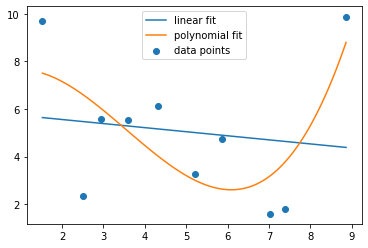

In [4]:
import numpy as np
import matplotlib.pyplot as plt

X = np.random.uniform(1, 10, 10)
Y = np.random.uniform(1, 10, 10)

A = np.vstack([X, np.ones(len(X))]).T
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
Y_linear = m*X + c

degree = 3
coefficients = np.polyfit(X, Y, degree)
poly = np.poly1d(coefficients)
Y_poly = poly(X)

mse_linear = np.mean((Y - Y_linear)**2)
mse_poly = np.mean((Y - Y_poly)**2)

ss_total = np.sum((Y - np.mean(Y))**2)

r2_linear = 1 - np.sum((Y - Y_linear)**2) / ss_total
r2_poly = 1 - np.sum((Y - Y_poly)**2) / ss_total

print("Linear MSE:", mse_linear)
print("Polynomial MSE:", mse_poly)

print("Linear R^2:", r2_linear)
print("Polynomial R^2:", r2_poly)

if r2_poly > r2_linear:
    print("Polynomial fit is better")
else:
    print("Linear fit is better")

t = np.linspace(min(X), max(X), 100)

plt.scatter(X, Y, label = 'data points')
plt.plot(t, m*t + c, label = 'linear fit')
plt.plot(t, poly(t), label = 'polynomial fit')
plt.legend()
plt.show()

Part B

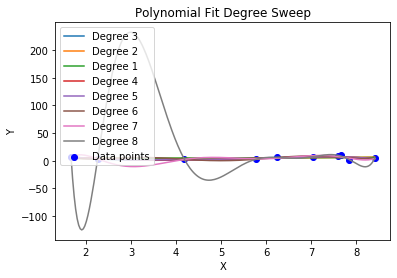

In [5]:
import numpy as np
import matplotlib.pyplot as plt

X = np.random.uniform(1, 10, 10)
Y = np.random.uniform(1, 10, 10)

plt.scatter(X, Y, color='blue', label='Data points')
t = np.linspace(min(X), max(X), 200)

results = []

for deg in range(3, 0, -1):
    coeffs = np.polyfit(X, Y, deg)
    poly = np.poly1d(coeffs)
    Y_poly = poly(X)
    mse_val = np.mean((Y - Y_poly)**2)
    r2_val = 1 - np.sum((Y - Y_poly)**2) / np.sum((Y - np.mean(Y))**2)
    results.append((deg, mse_val, r2_val))
    plt.plot(t, poly(t), label=f'Degree {deg}')

for deg in range(4, 9):
    coeffs = np.polyfit(X, Y, deg)
    poly = np.poly1d(coeffs)
    Y_poly = poly(X)
    mse_val = np.mean((Y - Y_poly)**2)
    r2_val = 1 - np.sum((Y - Y_poly)**2) / np.sum((Y - np.mean(Y))**2)
    results.append((deg, mse_val, r2_val))
    plt.plot(t, poly(t), label=f'Degree {deg}')

plt.title('Polynomial Fit Degree Sweep')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

Part C

MSE: 0.004828571428571423
R^2: 0.9974128957197967


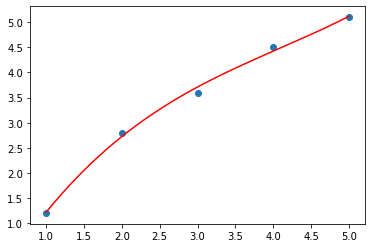

In [6]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([1, 2, 3, 4, 5])
Y = np.array([1.2, 2.8, 3.6, 4.5, 5.1])
degree = 3

V = np.vander(X, degree+1, increasing=True)
coeffs = np.linalg.lstsq(V, Y, rcond=None)[0]
Y_fit = V @ coeffs

mse = np.mean((Y - Y_fit)**2)
r2 = 1 - np.sum((Y - Y_fit)**2) / np.sum((Y - np.mean(Y))**2)

print("MSE:", mse)
print("R^2:", r2)

t = np.linspace(min(X), max(X), 200)
V_t = np.vander(t, degree+1, increasing=True)
plt.scatter(X, Y)
plt.plot(t, V_t @ coeffs, color='red')
plt.show()